In [36]:
import pandas as pd

df = pd.read_csv('data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            248 non-null    str    
 1   selic           248 non-null    float64
 2   ipca            248 non-null    float64
 3   ibc_br          248 non-null    float64
 4   preco_gasolina  248 non-null    float64
dtypes: float64(4), str(1)
memory usage: 9.8 KB


<Axes: xlabel='Date'>

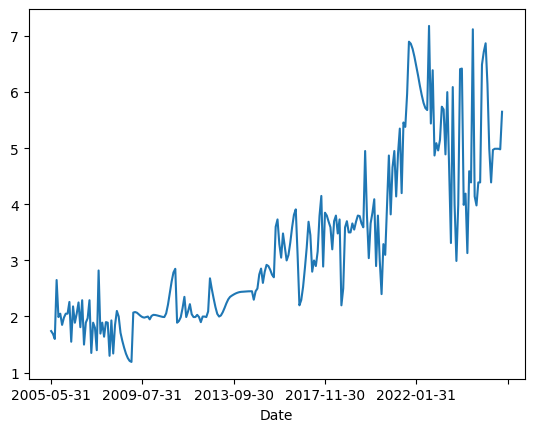

In [37]:
df.set_index('Date')['preco_gasolina'].plot()

In [38]:
df.head(5)

,Date,selic,ipca,ibc_br,preco_gasolina
0,2005-05-31,19.75,0.49,178129.5,1.740
1,2005-06-30,19.75,-0.02,179509.8,1.690
2,2005-07-31,19.75,0.25,181673.2,1.599
3,2005-08-31,19.75,0.17,186712.8,2.650
4,2005-09-30,19.50,0.35,184473.1,1.990


In [39]:
df.describe()

,selic,ipca,ibc_br,preco_gasolina
count,248.000000,248.000000,2.480000e+02,248.000000
mean,10.707661,0.445282,5.349174e+05,3.231409
std,3.768439,0.331610,2.538963e+05,1.456701
min,2.000000,-0.680000,1.769885e+05,1.190000
25%,8.187500,0.240000,3.253580e+05,2.039962
50%,11.250000,0.430000,5.042437e+05,2.809500
75%,13.750000,0.600000,6.756208e+05,3.967046
max,19.750000,1.620000,1.107951e+06,7.180000


In [40]:
# 1. Correção do Índice IPCA (Base 100, sem subtrair 1)
# Isso evita que o primeiro valor seja 0 (cujo log é infinito) 
# ou negativo, o que quebraria a função np.log()
df['ipca_index'] = 100 * ((1 + df['ipca'] / 100).cumprod())

# 2. Aplicando os Logaritmos
df['log_ipca'] = np.log(df['ipca_index'])
df['log_ibc'] = np.log(df['ibc_br'])
df['log_gasolina'] = np.log(df['preco_gasolina'])

# 3. Transformação da Selic para entrar no VECM
# Como ela já é uma taxa percentual, usamos a fórmula log(1 + taxa)
df['log_selic'] = np.log(1 + (df['selic'] / 100))

# 4. Criando o DataFrame final para rodar o modelo
# A ORDEM IMPORTA: O IPCA deve ser a primeira variável para o beta.1
df_vecm = df[[
    'log_ipca',     # <-- Voltou para a posição 1
    'log_selic',    
    'log_ibc',
    'log_gasolina'
]].dropna()

<Axes: >

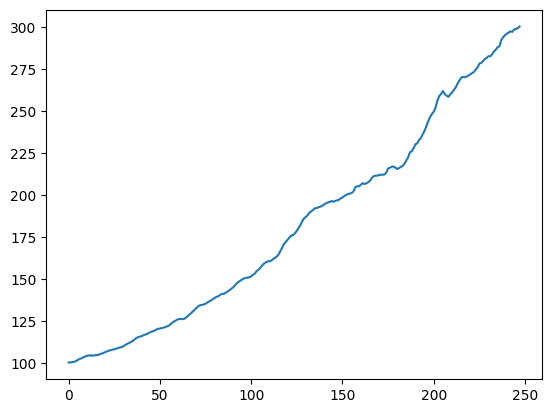

In [41]:
df['ipca_index'].plot()

In [42]:
df_vecm.head(5)

,log_ipca,log_selic,log_ibc,log_gasolina
0,4.610058,0.180236,12.090266,0.553885
1,4.609858,0.180236,12.097985,0.524729
2,4.612355,0.180236,12.109965,0.469378
3,4.614054,0.180236,12.137327,0.974560
4,4.617548,0.178146,12.125259,0.688135


In [43]:
endog = df_vecm[['log_ipca', 'log_ibc', 'log_gasolina', 'log_selic']]

In [44]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron


def test_stationarity(series, col):
    series = series.dropna()
    
    # ADF
    adf = adfuller(series)
    
    # PP
    pp = PhillipsPerron(series)
    
    # KPSS
    kpss_test = kpss(series, regression='c', nlags='auto')
    
    return {
        "Variavel": col,
        "ADF_pvalue": adf[1],
        "PP_pvalue": pp.pvalue,
        "KPSS_pvalue": kpss_test[1]
    }


resultados = []
for col in endog.columns:
    res = test_stationarity(df[col], col)
    resultados.append(res)

frame_final = pd.DataFrame(resultados)
frame_final

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15644\2436622687.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series, regression='c', nlags='auto')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15644\2436622687.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series, regression='c', nlags='auto')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15644\2436622687.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series, regression='c', nlags='auto')


,Variavel,ADF_pvalue,PP_pvalue,KPSS_pvalue
0,log_ipca,0.948101,0.964358,0.010000
1,log_ibc,0.568336,0.604843,0.010000
2,log_gasolina,0.819672,0.022735,0.010000
3,log_selic,0.000852,0.093466,0.074197


In [45]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen = coint_johansen(endog, det_order=0, k_ar_diff=1)

print(johansen.lr1)   # estatística trace
print(johansen.cvt)   # valores críticos

[97.67273843 27.26342334  7.56042234  2.9231524 ]
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


Em um primeiro resultado, foi possível identificar que, ao rodar johansen, foram encontrados 3 vetores de cointegração. sendo que, como a quantidade de vetores são iguais a quantidade de variaveis, isso significa que a série conjunta é estacionária, mesmo que individualmente sejam nao estacionarias.

In [46]:
from statsmodels.tsa.vector_ar.vecm import VECM

vecm = VECM(
    endog,
    k_ar_diff=1,
    coint_rank=1  # POSSUI NO MÁXIMO 1 VETOR (VALOR ENCONTRADO ATRAVES DE JOHANSEN)
)

vecm_fit = vecm.fit()

In [47]:
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation log_ipca
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
L1.log_ipca         0.5535      0.051     10.872      0.000       0.454       0.653
L1.log_ibc         -0.0171      0.005     -3.783      0.000      -0.026      -0.008
L1.log_gasolina    -0.0033      0.001     -3.305      0.001      -0.005      -0.001
L1.log_selic        0.0255      0.044      0.586      0.558      -0.060       0.111
Det. terms outside the coint. relation & lagged endog. parameters for equation log_ibc
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
L1.log_ipca         0.8075      0.717      1.126      0.260      -0.598       2.213
L1.log_ibc         -0.1823      0.064     -2.857      0.004      -0.3

log_ipca - 0.8410*log_ibc + 1.0828*log_gasolina = 0

### Isolando IPCA:
log(ipca)=0.8410⋅log(ibc)−1.0828⋅log(gasolina)


ou seja, 1% ↑ atividade → 0.84% ↑ inflação ; atividade foi significativa
no entanto, gasolina não foi significativo, ou seja, não há evidência estatística de relação de longo prazo entre preço da gasolina e inflação.



## Termo de correção de erro:
A inflação corrige desvios do equilíbrio de longo prazo, porém de forma lenta (0,0003).
IBC-br e gasolina foram não significativos.


## Curto prazo:
Inflação:

própria defasagem → significativa
ibc → impacto negativo
gasolina → impacto positivo (fraco)


IBC-Br
própria defasagem → significativa


Gasolina
própria defasagem → significativa
inflação → impacto positivo

## Resposta mais detalhada:

O modelo VECM estimado indicou a existência de uma relação de cointegração entre as variáveis, evidenciando um equilíbrio de longo prazo no sistema. A equação de cointegração mostrou que a atividade econômica possui relação positiva e estatisticamente significativa com a inflação, indicando que aumentos na atividade estão associados a elevações no nível de preços no longo prazo. Por outro lado, o preço da gasolina não apresentou significância estatística, não sendo possível afirmar sua influência no equilíbrio de longo prazo.

O termo de correção de erro foi significativo apenas na equação da inflação, com sinal negativo, indicando que essa variável é responsável pelo ajuste ao equilíbrio de longo prazo, ainda que de forma lenta. As demais variáveis não apresentaram mecanismos de ajuste significativos.

No curto prazo, observou-se que a inflação apresenta forte persistência, sendo influenciada por sua própria defasagem e pela atividade econômica. A variável preço da gasolina também apresentou comportamento inercial, além de influência da inflação.

A taxa Selic, incluída como variável exógena, não apresentou significância estatística, indicando ausência de efeito relevante no curto prazo sobre as variáveis analisadas.

# Alterações:

In [48]:
import statsmodels.api as sm

# Descobrindo o número ideal de meses (lags) para o modelo
modelo_var = sm.tsa.VAR(df_vecm)
resultados_selecao = modelo_var.select_order(maxlags=12)
print(resultados_selecao.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -17.82      -17.76   1.831e-08      -17.79
1       -32.99      -32.70   4.693e-15      -32.87
2       -33.42     -32.89*   3.069e-15      -33.20
3       -33.56      -32.80   2.658e-15      -33.25
4       -33.81      -32.82   2.065e-15     -33.41*
5       -33.81      -32.57   2.085e-15      -33.31
6       -33.75      -32.28   2.202e-15      -33.16
7       -33.85      -32.14   2.010e-15      -33.16
8       -33.78      -31.84   2.160e-15      -33.00
9       -33.73      -31.56   2.268e-15      -32.85
10      -33.69      -31.29   2.361e-15      -32.72
11      -33.84      -31.20   2.052e-15      -32.77
12     -34.00*      -31.13  1.750e-15*      -32.84
--------------------------------------------------


In [49]:
import statsmodels.api as sm

# O k_ar_diff = 3 significa que o modelo base (VAR) tem 4 lags.
# coint_rank = 1 porque o seu Teste de Johansen confirmou exatamente 1 vetor.
vecm = sm.tsa.VECM(
    df_vecm, 
    k_ar_diff=3, 
    coint_rank=1, 
    deterministic='ci'
)

resultado_vecm = vecm.fit()
print(resultado_vecm.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation log_ipca
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
L1.log_ipca         0.5153      0.064      8.111      0.000       0.391       0.640
L1.log_selic        0.1140      0.055      2.082      0.037       0.007       0.221
L1.log_ibc         -0.0154      0.005     -3.238      0.001      -0.025      -0.006
L1.log_gasolina     0.0007      0.001      0.728      0.466      -0.001       0.003
L2.log_ipca         0.0530      0.072      0.739      0.460      -0.088       0.194
L2.log_selic        0.0707      0.051      1.389      0.165      -0.029       0.170
L2.log_ibc          0.0015      0.005      0.312      0.755      -0.008       0.011
L2.log_gasolina     0.0025      0.001      2.354      0.019       0.000       0.005
L3.log_ipca        -0.0685      0.064     -1.062      0.288      -0.195 